# Colocation of In-Situ Ocean Profiles with Tropical Cyclone Tracks

This notebook queries tropical cyclone (TC) track data from Argovis, then finds all colocated Argo, CCHDO, and EasyOcean profiles within a configurable radius and time window around each track point. The before/after temperature profiles reveal the ocean's thermal response to storm passage.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

## Notebook structure

- The main notebook colocates Argo, CCHDO, and EasyOcean profiles with a single tropical cyclone's track and computes before/after temperature and salinity changes.
- **Part 2** (optional) — repeat the analysis for a different storm.
- **Student Work** — guided questions throughout.

## Learning Goals

By the end of this activity, you will be able to:

1. **Colocate ocean profiles with TC tracks** — query Argo profiles within a spatial and temporal window around each track point and deduplicate overlapping results.
2. **Identify the subsurface ocean response to TC passage** — detect cooling, mixed layer deepening, and salinity changes in before/after profile pairs.
3. **Interpret mean delta profiles** — quantify the net TC-driven ocean response averaged across storms and track points.
4. **Evaluate observational limitations** — assess how precipitation signals, sampling geometry, and the seasonal cycle can bias the before/after comparison.
5. **Compare TC responses across storms and basins** — explore how storm intensity, translation speed, and background ocean state shape the observed signal.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ───────────────────────────
from argovisHelpers import helpers as avh
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from datetime import timedelta
from dateutil import parser
warnings.filterwarnings("ignore", category=UserWarning, module="scipy")
warnings.filterwarnings("ignore", message="Internal error in root finding")
warnings.filterwarnings("ignore", category=RuntimeWarning)

APIKEY  = 'guest'
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `get_yearly_storm_tracks` — query TC track data year-by-year in monthly chunks
- `radius_to_box` — convert center + radius to a bounding box for `queryProfile`
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `plot_maps` — scatter profile locations on a map
- `compare_profiles` — plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`
- `average_profiles_dict` — compute level-by-level mean profiles across a list of Profile objects, returned as a single-entry dict ready for `compare_profiles`
- `deduplicate_storm_results` — assign each profile to its nearest track point; remove spatial redundancy
- `get_flat_profiles` — recursively flatten nested lists/dicts of Profile objects
- `haversine_km` — great-circle distance between two points
- `infer_dataset` — infer the dataset key (`argo`, `cchdo`, or `easyocean`) for a profile from its metadata
- `interpolate_to_grid` — interpolate a single profile variable onto a common pressure grid
- `extract_profile_data` — extract temperature, salinity, MLD, and potential density from a profile, interpolated onto the common pressure grid
- `compute_derived_properties` — compute SA, CT, potential density, MLD (3 methods), and N² for each profile
- `build_pair_dataframe` — select matched before/after pairs and compute ΔT, ΔS, ΔPD, ΔMLD
- `plot_storm_insitu` — two maps per storm: profile locations and timing relative to passage
- `plot_one_storm` — plot a single storm by ID
- `plot_storm_profile_pairs` — before/after profile comparison at each track point
- `plot_mean_across_storms` — mean ΔT and ΔS profiles across all storms and pairs

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions import traverse_query, plot_maps, compare_profiles, average_profiles_dict
from notebook_helpers.functions_TC import (
    get_yearly_storm_tracks, get_flat_profiles, deduplicate_storm_results,
    compute_derived_properties, build_pair_dataframe,
    plot_storm_insitu, plot_storm_profile_pairs, plot_one_storm,
    radius_to_box, haversine_km, infer_dataset,
    interpolate_to_grid, extract_profile_data,
    plot_mean_across_storms
)

## Setup: configuration

✏️ **Student Work — Configuration**

All downstream cells read from the variables defined here.

- **`target_year`**: year to fetch TC tracks for
- **`target_ids`**: list of storm IDs to query (e.g. `["AL152017"]`); leave `[]` for all storms in the year
- **`radius_km`**: search radius around each track point for colocated profiles
- **`delta_days`**: time window (±days) around each track point

> **Tip:** If you don't know the exact storm ID, leave `target_ids = []` and run the next two cells first — they will fetch all tracks and print each storm ID with its active date range. Then come back here and set `target_ids` to the storm(s) you want.
>
> **💡 Start with 1–2 storms:** fetching profiles for every track point of a single storm can take a few minutes; querying many storms at once will multiply that wait time significantly. Get familiar with the workflow on one or two storms before expanding your query.

In [3]:
# MODIFY HERE
# ── Query configuration ───────────────────────────────────────────────────────
target_year = 2017

# One storm:
#   target_ids = ["AL152017"]
# Two storms:
#   target_ids = ["AL152017", "AL092017"]
# All storms in the year (may take several minutes):
#   target_ids = []
target_ids  = ["AL152017"]

radius_km   = 150
delta_days  = 10

# ── In-situ datasets and variables ───────────────────────────────────────────
insitu = {
    "argo":      "temperature,1,salinity,1",
    "cchdo":     "salinity,temperature",
    "easyocean": "ctd_salinity,ctd_temperature",
}

# ── Interpolation levels ──────────────────────────────────────────────────────
interpolation_levels = avh.rg_levels()

# ── Plotting conventions ──────────────────────────────────────────────────────
TIME_LINESTYLES = ['-', '--', ':', '-.']
DEPTH_YLIM      = 300  # dbar; set None for full depth

## Step 1 — Fetch TC track data

TC track data is queried from the Argovis `tc` collection month-by-month for the target year. Each storm is assembled into a dictionary keyed by storm ID, with a time-sorted list of track points containing coordinates, timestamps, and wind speed (where available).

Use this list of TCs below to select a TC (or more TCs) you would like to query data for.

In [4]:
# ── Step 1: Fetch TC tracks — run, do not modify ───────────────────────────
# --- EXECUTION ---
all_tracks = get_yearly_storm_tracks(target_year, APIKEY)


--- Fetching TC data: 2017-01 ---
--- Fetching TC data: 2017-02 ---
--- Fetching TC data: 2017-03 ---
--- Fetching TC data: 2017-04 ---
--- Fetching TC data: 2017-05 ---
--- Fetching TC data: 2017-06 ---
--- Fetching TC data: 2017-07 ---
--- Fetching TC data: 2017-08 ---
--- Fetching TC data: 2017-09 ---
--- Fetching TC data: 2017-10 ---
--- Fetching TC data: 2017-11 ---
--- Fetching TC data: 2017-12 ---
Fetching names for 94 unnamed storm(s)…
Successfully organized 94 tracks.


In [5]:
# ── Print available storms — run, do not modify ────────────────────────────
print(f"Total Storms: {len(all_tracks)}")
for key in sorted(all_tracks.keys()):
    data  = all_tracks[key]
    name  = data.get('name', 'N/A')
    times = [pt['time'] for pt in data['regions']]
    t_min = min(times)[:10]
    t_max = max(times)[:10]
    print(f" • ID {key} | name: {name} | time period: {t_min} → {t_max}")

Total Storms: 94
 • ID AL012017 | name: ARLENE | time period: 2017-04-16 → 2017-04-22
 • ID AL022017 | name: BRET | time period: 2017-06-18 → 2017-06-20
 • ID AL032017 | name: CINDY | time period: 2017-06-19 → 2017-06-24
 • ID AL042017 | name: FOUR | time period: 2017-07-05 → 2017-07-07
 • ID AL052017 | name: DON | time period: 2017-07-17 → 2017-07-18
 • ID AL062017 | name: EMILY | time period: 2017-07-30 → 2017-08-02
 • ID AL072017 | name: FRANKLIN | time period: 2017-08-06 → 2017-08-10
 • ID AL082017 | name: GERT | time period: 2017-08-12 → 2017-08-18
 • ID AL092017 | name: HARVEY | time period: 2017-08-16 → 2017-09-02
 • ID AL112017 | name: IRMA | time period: 2017-08-30 → 2017-09-13
 • ID AL122017 | name: JOSE | time period: 2017-09-04 → 2017-09-25
 • ID AL132017 | name: KATIA | time period: 2017-09-05 → 2017-09-09
 • ID AL142017 | name: LEE | time period: 2017-09-14 → 2017-09-30
 • ID AL152017 | name: MARIA | time period: 2017-09-16 → 2017-10-02
 • ID AL162017 | name: NATE | time 

## Step 2 — Query colocated in-situ profiles
For each track point, a circular search region with radius `radius_km` is defined, and all in-situ profiles within that region and within ±`delta_days` are fetched via `traverse_query`. Results are stored per storm, one entry per track point that returned data.

Depending on the number of storms and track points, this cell may take several minutes.

In [6]:
# ── Step 2: Query colocated in-situ profiles — run, do not modify ──────────

all_insitu_results   = {}
all_result_track_pts = {}

print("--- Starting Search & Processing ---")
active_tracks = {k: v for k, v in all_tracks.items() if not target_ids or k in target_ids}

for storm_id, data in active_tracks.items():
    print(f" Querying: {storm_id} ({len(data['regions'])} track points)...")
    storm_results = []
    storm_pts     = []

    for pt in data['regions']:
        t = parser.parse(pt['time'])
        t_window = [{
            "startDate": (t - timedelta(days=delta_days)).strftime('%Y-%m-%dT%H:%M:%SZ'),
            "endDate":   (t + timedelta(days=delta_days)).strftime('%Y-%m-%dT%H:%M:%SZ'),
        }]
        box = radius_to_box(pt['center'], radius_km)
        try:
            res = traverse_query(
                [{"box": box}], t_window, insitu,
                avh.queryProfile, APIKEY, APIROOT,
            )
            if res:
                storm_results.append(res)
                storm_pts.append(pt)
        except Exception:
            pass

    all_insitu_results[storm_id]   = storm_results
    all_result_track_pts[storm_id] = storm_pts
    print(f" Done. Found {len(storm_results)} time windows with matches.")

print("Job complete.")

--- Starting Search & Processing ---
 Querying: AL152017 (68 track points)...
 Done. Found 68 time windows with matches.
Job complete.


## Step 3 — Deduplicate profiles

Each profile is assigned to its single nearest track point. Profiles appearing in multiple overlapping windows are kept only for their best-matching track point. Within each track point, spatially redundant profiles of the same timing type (both before or both after TC passage) are thinned by keeping the one nearest the track center — leaving at most one before and one after candidate per track point.

The final before/after pairing is performed in Step 5, where the pair with minimum spatial distance between the two profiles is selected; ties are broken by minimum time gap between the two profiles (|t_after − t_before|). A smaller time gap reduces the chance that the delta signal reflects other variability rather than the TC itself.

In [7]:
# ── Step 3: Deduplicate profiles — run, do not modify ──────────────────────
all_insitu_deduplicated = {}
for storm_id, results in all_insitu_results.items():
    track_pts = all_result_track_pts[storm_id]
    deduped = deduplicate_storm_results(
        results, track_pts,
        radius_km=radius_km,
        # max_pair_dist_km=100,  # override spatial redundancy threshold if needed
    )
    n_before = sum(len(get_flat_profiles(s)) for s in results if s)
    n_after  = sum(len(s) for s in deduped)
    print(f"  {storm_id}: {n_before} → {n_after} profiles ({n_before - n_after} duplicates removed)")
    all_insitu_deduplicated[storm_id] = deduped
print("Deduplication complete.")

  AL152017: 160 → 53 profiles (107 duplicates removed)
Deduplication complete.


In [8]:
# ── Check profiles outside search radius — run, do not modify ──────────────
print(f"Profiles outside radius ({radius_km} km):")
found = False
for storm_id, steps in all_insitu_deduplicated.items():
    for i, (step, pt) in enumerate(zip(steps, all_result_track_pts[storm_id])):
        tc_lon, tc_lat = pt['center']
        for p in step:
            dist = haversine_km(tc_lon, tc_lat, p.longitude, p.latitude)
            if dist > radius_km:
                print(f"  {storm_id} step {i:02d} | {p.id} | {dist:.1f} km")
                found = True
if not found:
    print("  None — all profiles within radius.")

Profiles outside radius (150 km):
  None — all profiles within radius.


## Step 4 — Compute derived properties

For each unique profile, compute absolute salinity (SA), conservative temperature (CT), potential density (σ₀), mixed layer depth (MLD, three criteria), N², and buoyancy oscillation period. All results are stored back onto the Profile object.

In [9]:
# ── Step 4: Compute derived properties — run, do not modify ────────────────
print("--- Computing derived properties ---")
for storm_id, steps in all_insitu_deduplicated.items():
    n_ok, n_fail = 0, 0
    for step in steps:
        for p in step:
            try:
                compute_derived_properties(p)
                n_ok += 1
            except Exception as e:
                print(f"    {getattr(p, 'id', '?')} | {type(e).__name__}: {e}")
                n_fail += 1
    print(f"  {storm_id}: {n_ok} ok, {n_fail} failed")
print("Done.")

--- Computing derived properties ---
    6901172_118 | MLD skipped: shallowest level 25.3 dbar is below the 10-dbar reference
    6901150_161 | MLD skipped: shallowest level 23.4 dbar is below the 10-dbar reference
  AL152017: 53 ok, 0 failed
Done.


## Step 5 — Select before/after pairs and compute deltas

For each track point, find the best matched before/after profile pair. Pairing rules:
1. Both profiles must be within `radius_km` of the track point.
2. Distance between the two profiles must be ≤ `max_pair_dist_km`.
3. Keep the pair with minimum spatial distance between profiles.
4. Tiebreak: minimum time gap between the two profiles (|t_after − t_before|). A smaller time gap reduces the chance that the delta signal reflects other variability (seasonal cycle, mesoscale eddies) rather than the TC itself.
5. Each profile appears in at most one pair.

**`max_pair_dist_km`** controls the maximum allowed distance between the before and after profile in a pair. It is independent of `radius_km`:
- `radius_km` controls how far a profile can be from the **track point**
- `max_pair_dist_km` controls how far the **before and after profiles** can be from **each other**

By default `max_pair_dist_km = radius_km`, but they can be set independently. For example:
```python
radius_km        = 150   # each profile must be within 150 km of the track point
max_pair_dist_km = 100   # but the before/after pair must be within 100 km of each other
```
A smaller `max_pair_dist_km` gives cleaner pairs (the two profiles sample nearly the same location) but may reduce the number of valid pairs. A larger value recovers more pairs at the cost of increased spatial noise in the delta signals.

Outputs:
- `all_paired`: nested dict with full vertical profiles (T, S, PD, MLD, and after−before deltas)
- `df_pairs`: flat table of scalar values for mapping

In [10]:
# ── Step 5: Build before/after pairs — run, do not modify ─────────────────
all_paired, df_pairs = build_pair_dataframe(
    all_insitu_deduplicated,
    all_result_track_pts,
    interpolation_levels,
    radius_km=radius_km,
    # max_pair_dist_km=150,  # defaults to radius_km
)

  AL152017: 25 before, 28 after profiles
  AL152017: 18 pairs assigned

Built dataframe: 18 pairs across 1 storms


In [11]:
# ── Pair summary table — run, do not modify ────────────────────────────────
df_pairs[['storm_id', 'track_time', 'pair_dist_km', 'pair_dt_hours', 'pair_dt_days',
           'MLD_before', 'MLD_after', 'delta_MLD']]

,storm_id,track_time,pair_dist_km,pair_dt_hours,pair_dt_days,MLD_before,MLD_after,delta_MLD
0,AL152017,2017-09-19 00:00:00,4.35,240.07,10.00,11.395585,37.918265,26.522680
1,AL152017,2017-10-01 06:00:00,13.61,238.28,9.93,NaN,35.262336,NaN
2,AL152017,2017-09-19 18:00:00,17.87,233.33,9.72,15.825378,15.428552,-0.396827
3,AL152017,2017-09-19 06:00:00,33.78,239.20,9.97,10.744566,17.800925,7.056359
4,AL152017,2017-09-29 00:00:00,38.19,232.87,9.70,71.657568,68.480796,-3.176771
5,AL152017,2017-09-28 06:00:00,42.19,144.25,6.01,10.483966,26.102484,15.618518
6,AL152017,2017-09-22 12:00:00,50.55,260.87,10.87,65.538175,40.440872,-25.097303
7,AL152017,2017-09-24 18:00:00,53.14,232.90,9.70,31.530501,58.830027,27.299525
8,AL152017,2017-09-27 12:00:00,56.64,238.55,9.94,10.265033,12.448795,2.183762
9,AL152017,2017-09-30 18:00:00,57.40,95.73,3.99,32.591604,34.255465,1.663861


## Visualization — Storm track and profile locations

Two maps are generated automatically per storm, plus an optional third:

- **Top map:** all profiles returned by the API (pre-deduplication), plotted on a satellite imagery background (yellow markers). Duplicate profiles will simply overlap. The storm track is colored by storm class following NHC/JTWC conventions (green = Depression, yellow = Storm, red = Hurricane/Typhoon, magenta = Super Typhoon, gray = Extratropical).
- **Bottom map:** only the final selected before/after pairs (one per track point), colored by days relative to TC passage (blue = before, red = after). Markers carry a black outline so light-shaded profiles near zero time offset remain visible.
- **Optional map (separate cell below):** the same final before/after pairs as the bottom map, but drawn with the simpler scatter style used for the top map by calling `plot_maps` directly — before profiles in blue, after profiles in red, with no track-timing color scale.

> **Note:** The bottom map already restricts to the final pairs — the optional cell below is only useful if you specifically want the plain `plot_maps` scatter style instead of the track-timing color scale.

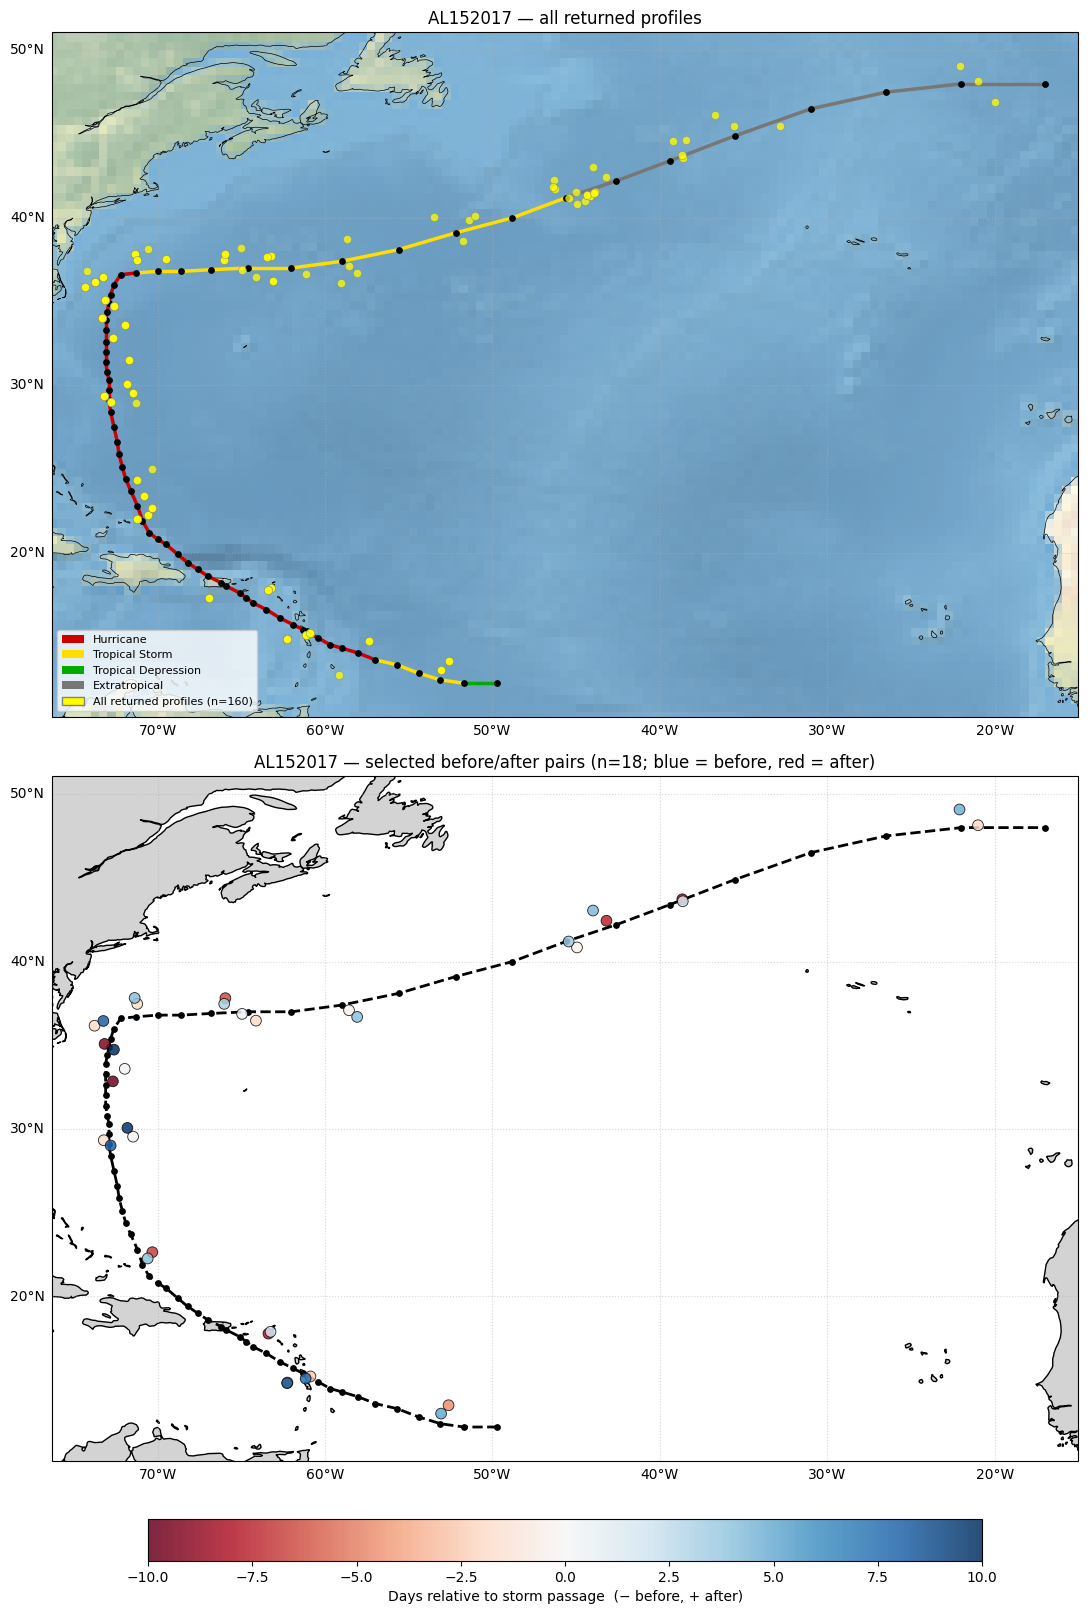

In [12]:
# ── Storm track and profile location maps — run, do not modify ─────────────
for storm_id in all_insitu_deduplicated:
    plot_storm_insitu(
        storm_id,
        all_result_track_pts[storm_id],
        all_insitu_results[storm_id], # all returned profiles (pre-deduplication) in Map 1
        radius_km=radius_km,
        delta_days=delta_days,
        all_paired_storm=all_paired.get(storm_id), # selected pairs in Map 2
    )

# Single storm:
# plot_one_storm('AL062018', all_insitu_deduplicated, all_result_track_pts,
#                radius_km=radius_km, delta_days=delta_days,
#                all_insitu_results=all_insitu_results, all_paired=all_paired)

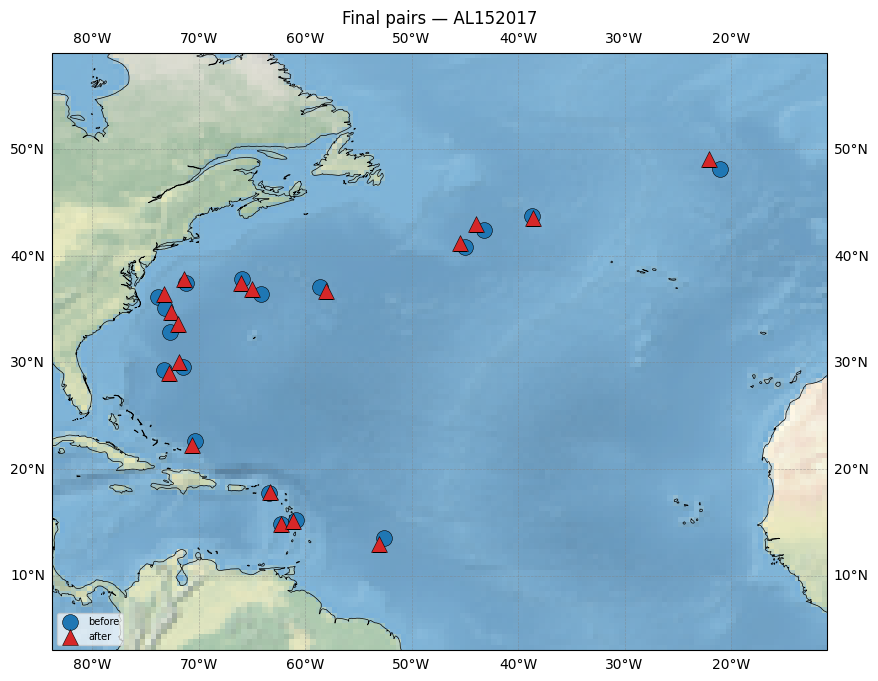

In [13]:
# ── Optional: scatter-style map of ONLY the final pairs — run, do not modify ──
# Reuses plot_maps restricted to the final before/after pairs.
meta_keys = {'track_lon', 'track_lat', 'track_time',
             'pair_dist_km', 'pair_dt_hours', 'pair_dt_days'}

for storm_id, steps in all_paired.items():
    b_lon, b_lat, a_lon, a_lat = [], [], [], []
    for entry in steps.values():
        ds = next(k for k in entry if k not in meta_keys)
        b, a = entry[ds]['before'], entry[ds]['after']
        b_lon.append(b['longitude']); b_lat.append(b['latitude'])
        a_lon.append(a['longitude']); a_lat.append(a['latitude'])

    plot_maps(
        [b_lat, a_lat],       
        [b_lon, a_lon],
        title=f"Final pairs — {storm_id}",
        labels=["before", "after"],
        colors=["tab:blue", "tab:red"],
        markersize=7,
    )

## Visualization — Before/after profiles at each track point

For each assigned pair, before (dashed) and after (solid) vertical profiles of temperature, salinity, and potential density.

In [14]:
# Run this before the plot call to inspect one pair
storm_id = list(all_paired.keys())[0]
step_idx = list(all_paired[storm_id].keys())[0]
entry = all_paired[storm_id][step_idx]
ds = [k for k in entry if k not in (
      'track_lon','track_lat','track_time',
      'pair_dist_km','pair_dt_hours', 'pair_dt_days')][0]

print("dataset key:", ds)
print("before keys:", list(entry[ds]['before'].keys()))
print("temperature sample:", entry[ds]['before']['temperature'][:5])
print("salinity sample:", entry[ds]['before']['salinity'][:5])
print("potential_density sample:", entry[ds]['before']['potential_density'][:5])

dataset key: argo
before keys: ['profile_id', 'timestamp', 'longitude', 'latitude', 'pressure', 'temperature', 'salinity', 'potential_density', 'MLD', 'MLD_temperature', 'MLD_density', 'MLD_potdensity']
temperature sample: [        nan 29.653999   29.49836309 29.15933378 28.276501  ]
salinity sample: [        nan 34.42606223 34.64468874 35.15407798 36.02749314]
potential_density sample: [          nan 1021.29319041 1021.50977125 1022.00478651 1022.95204328]


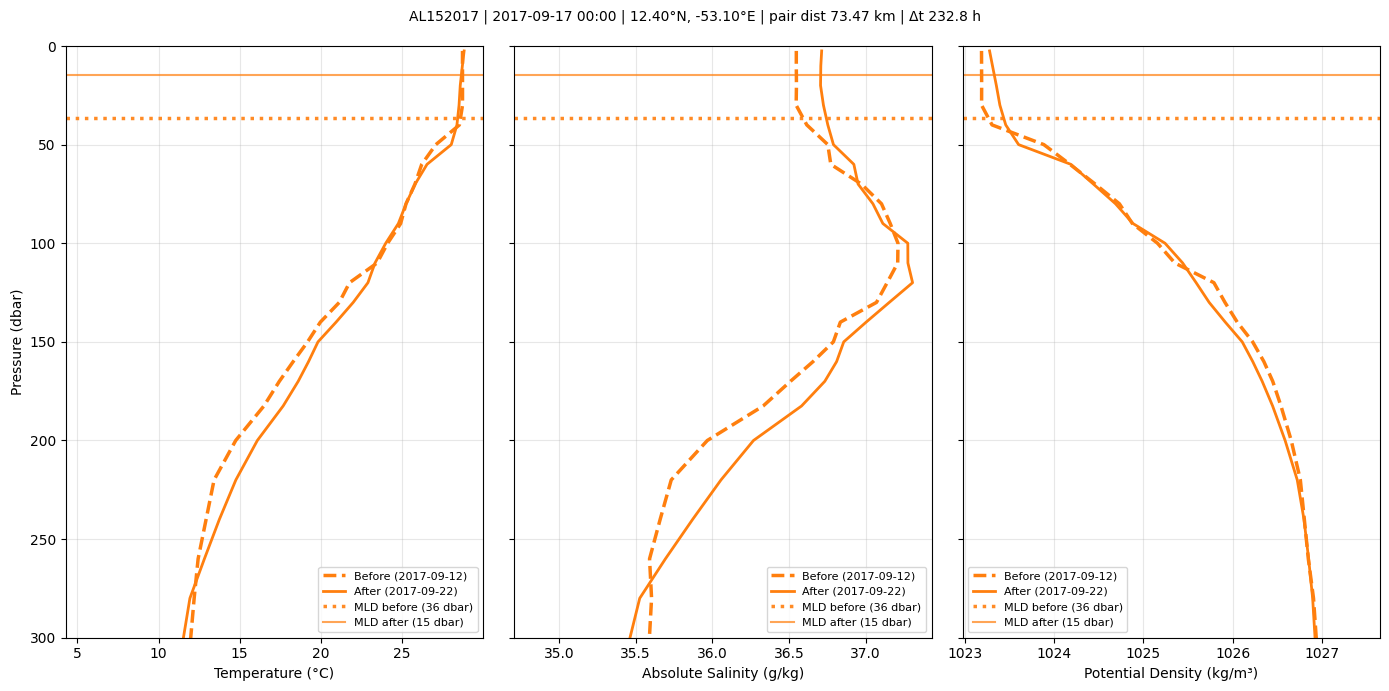

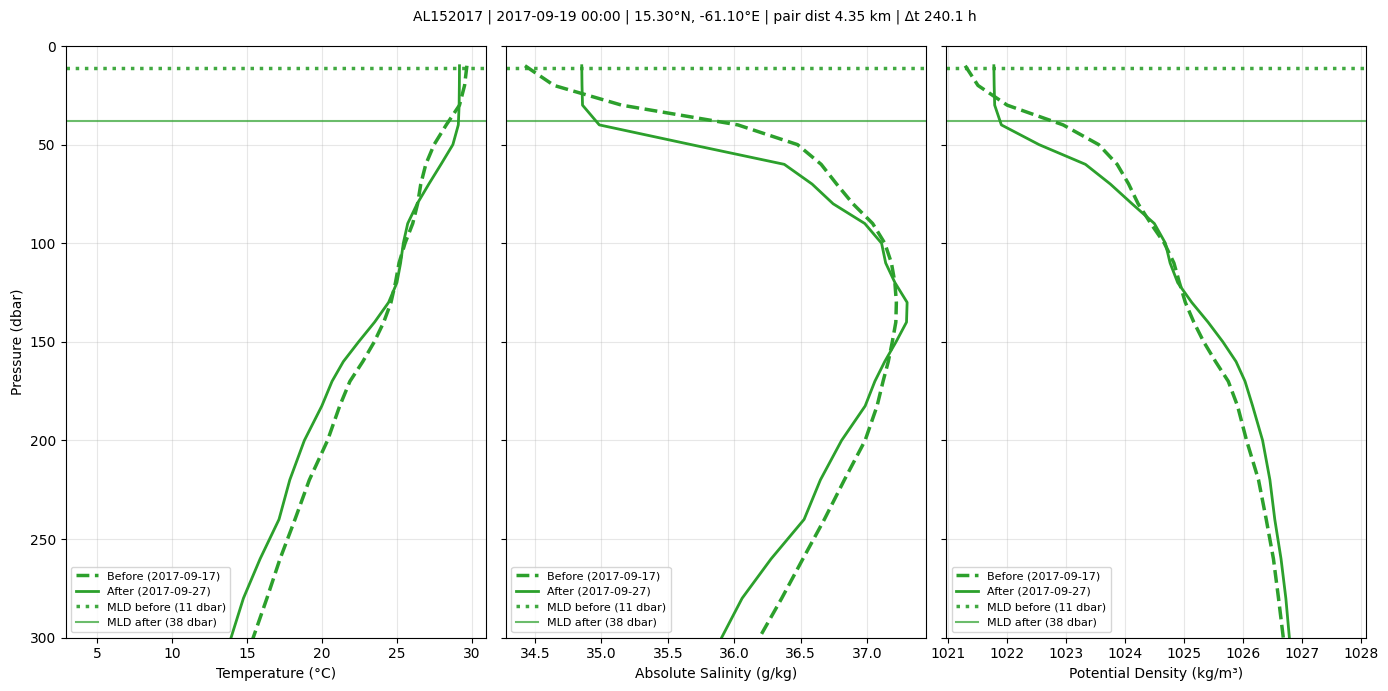

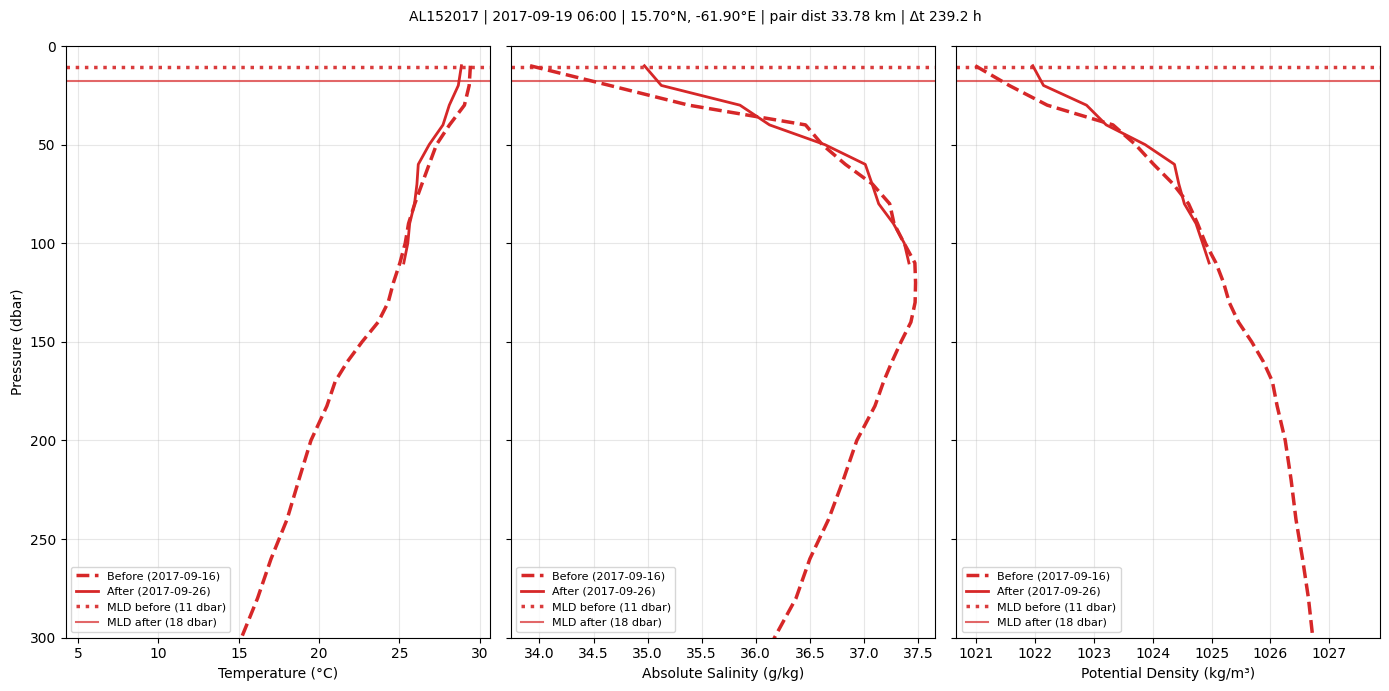

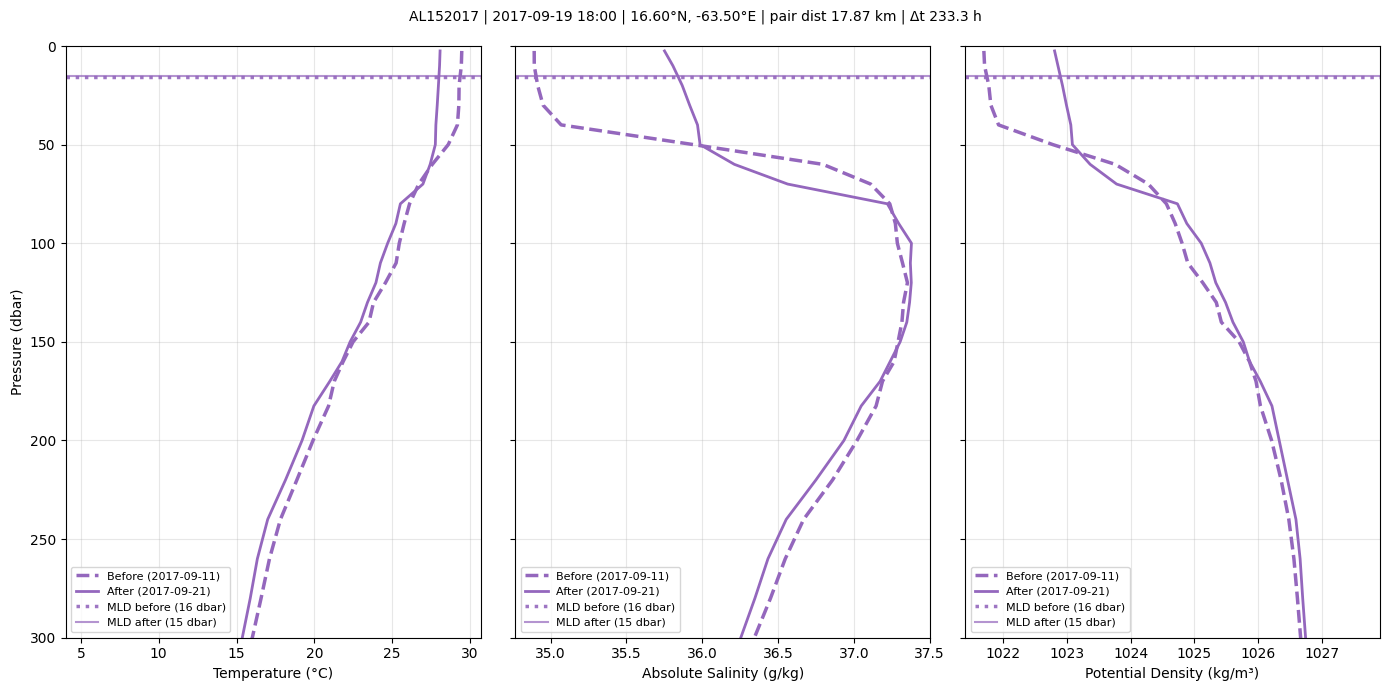

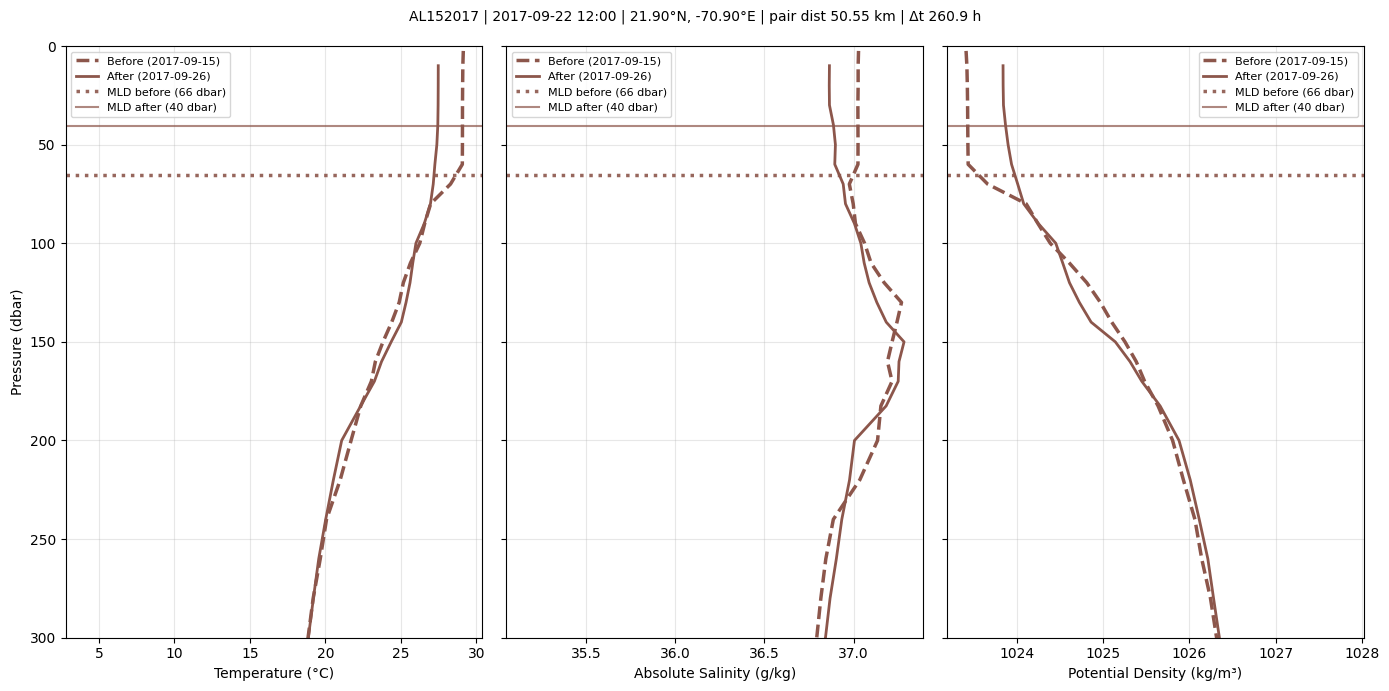

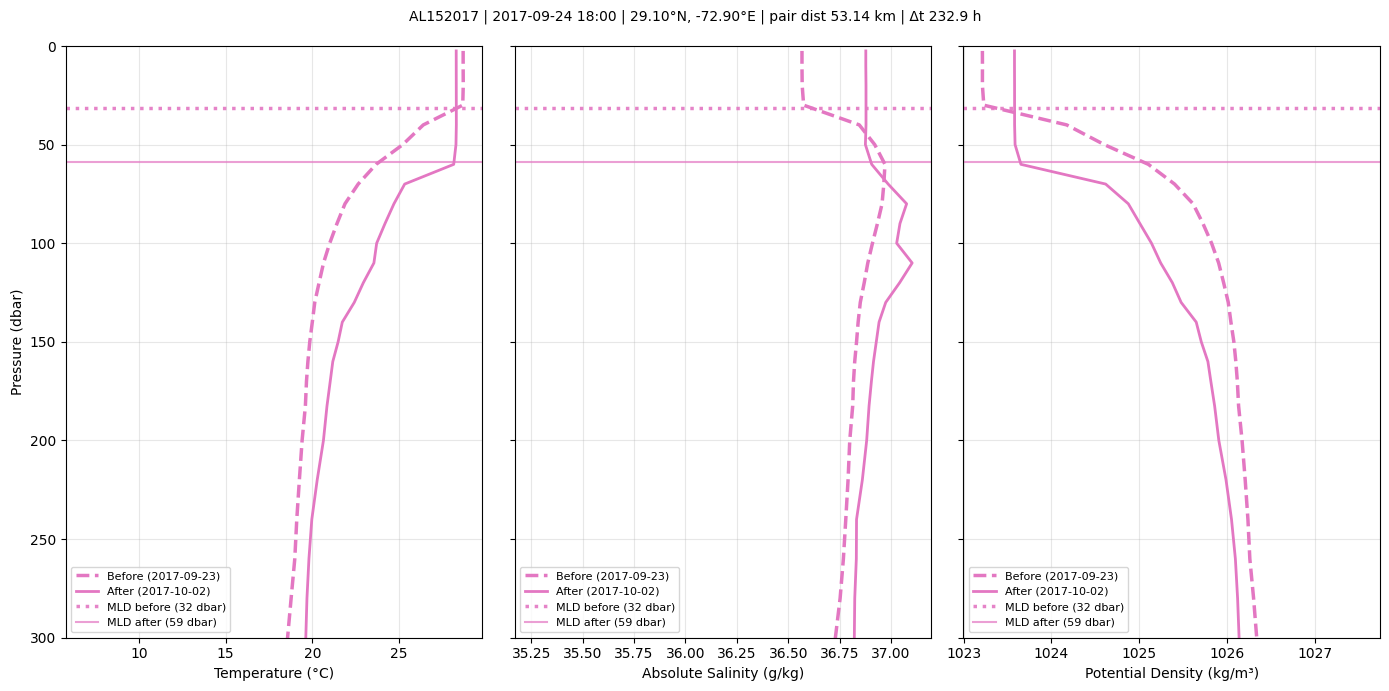

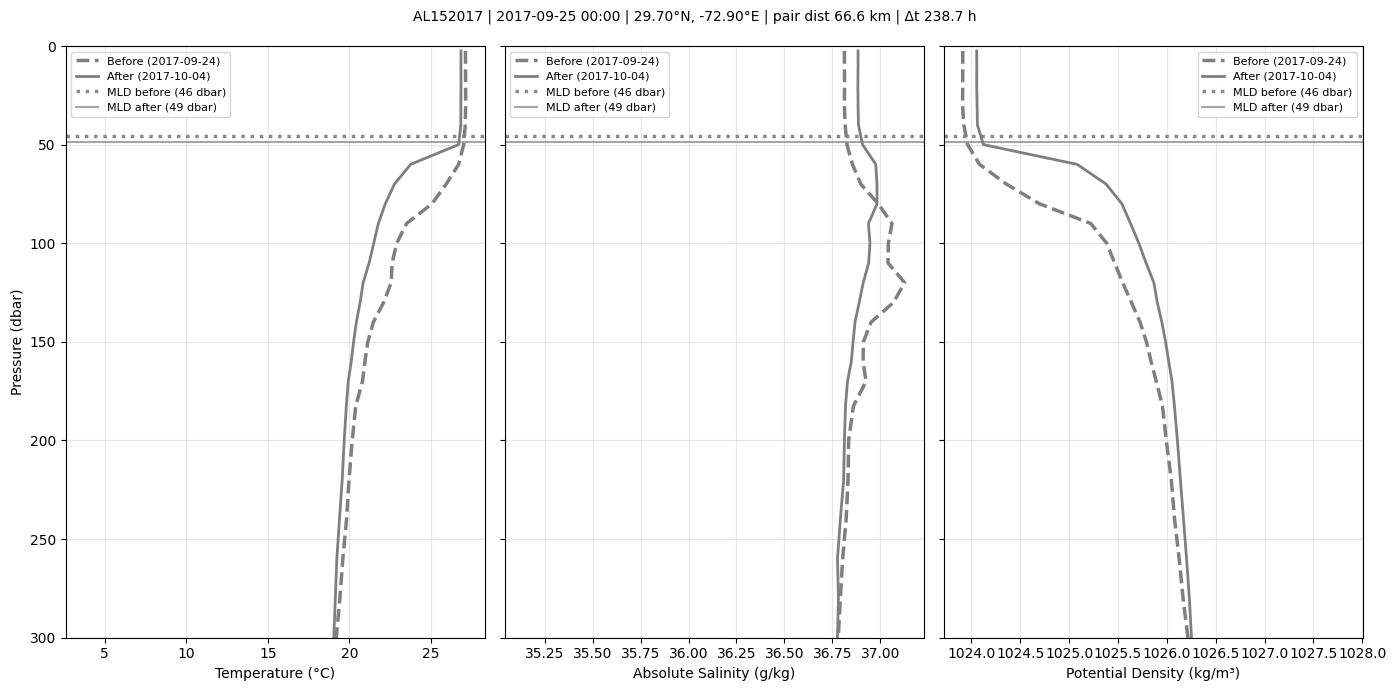

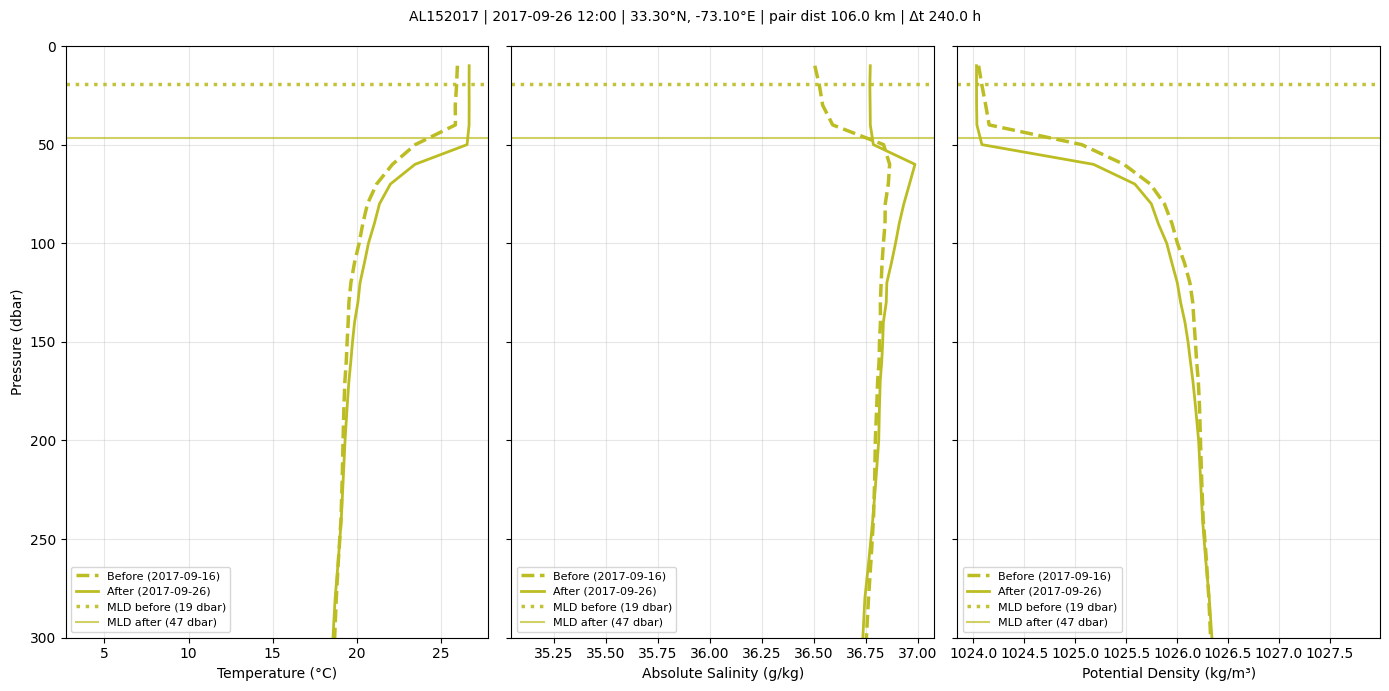

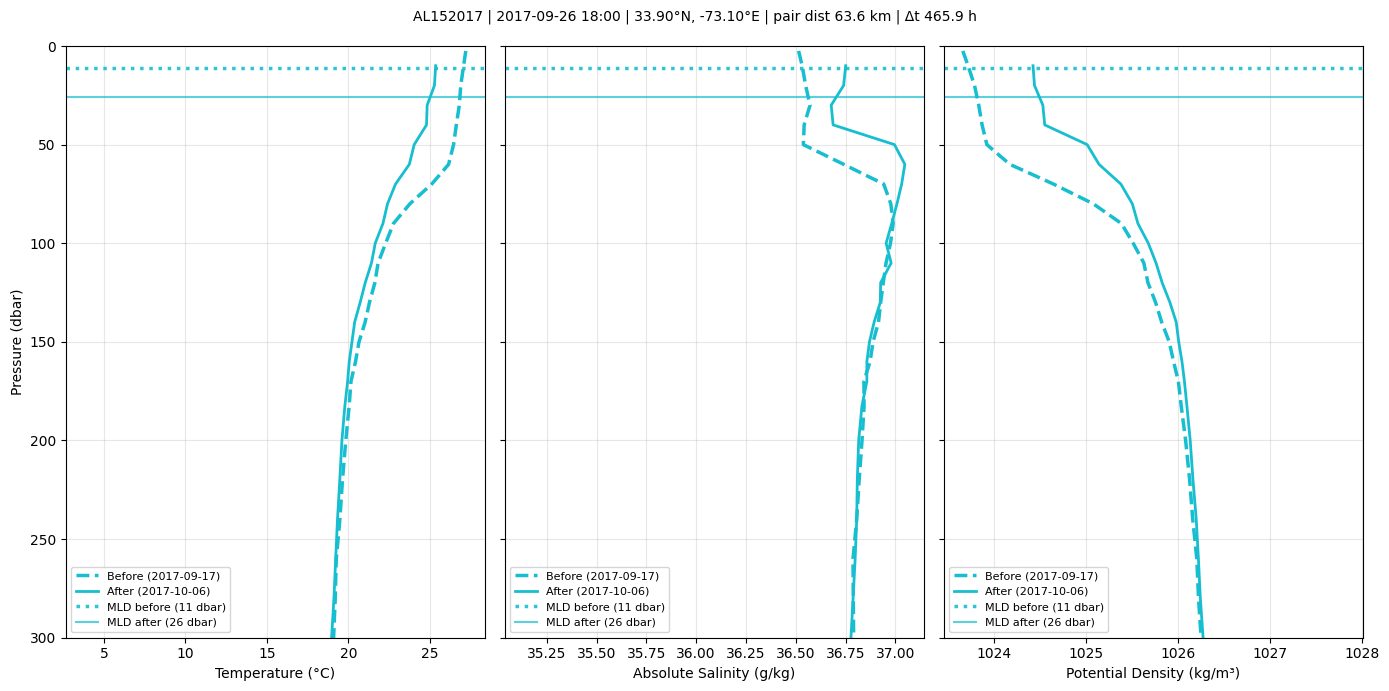

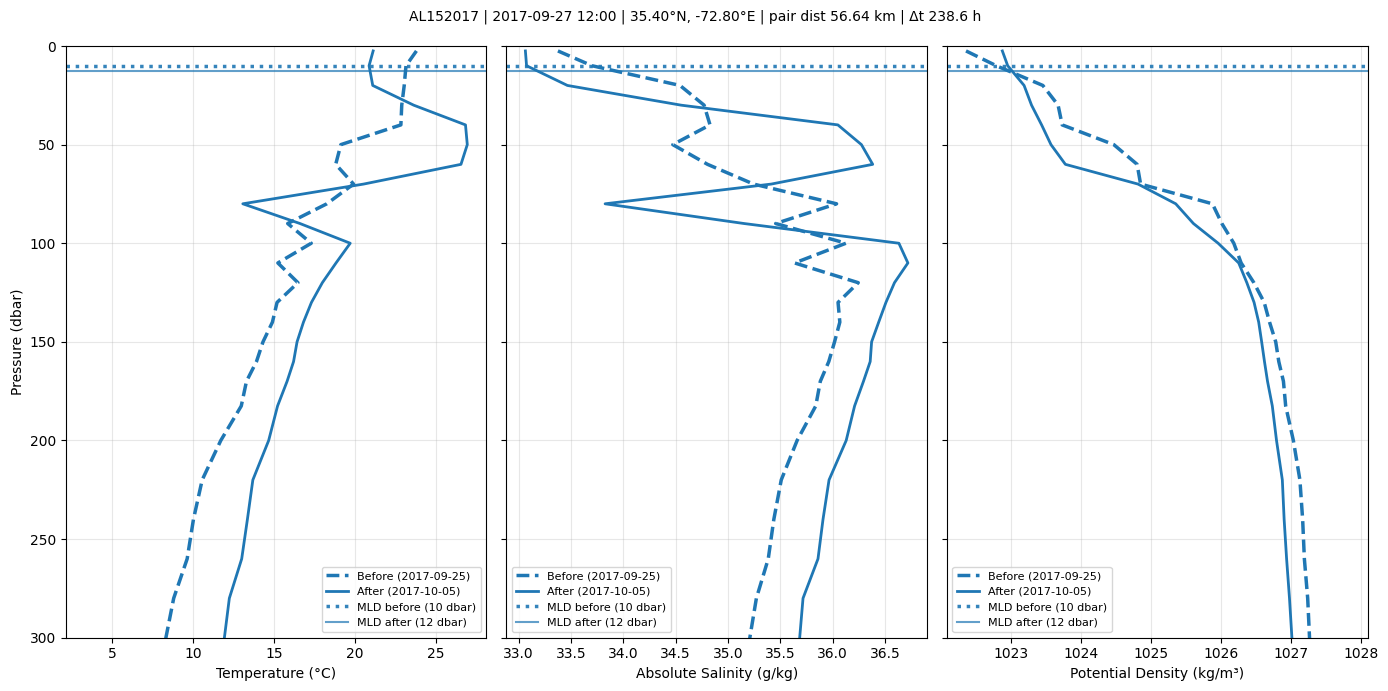

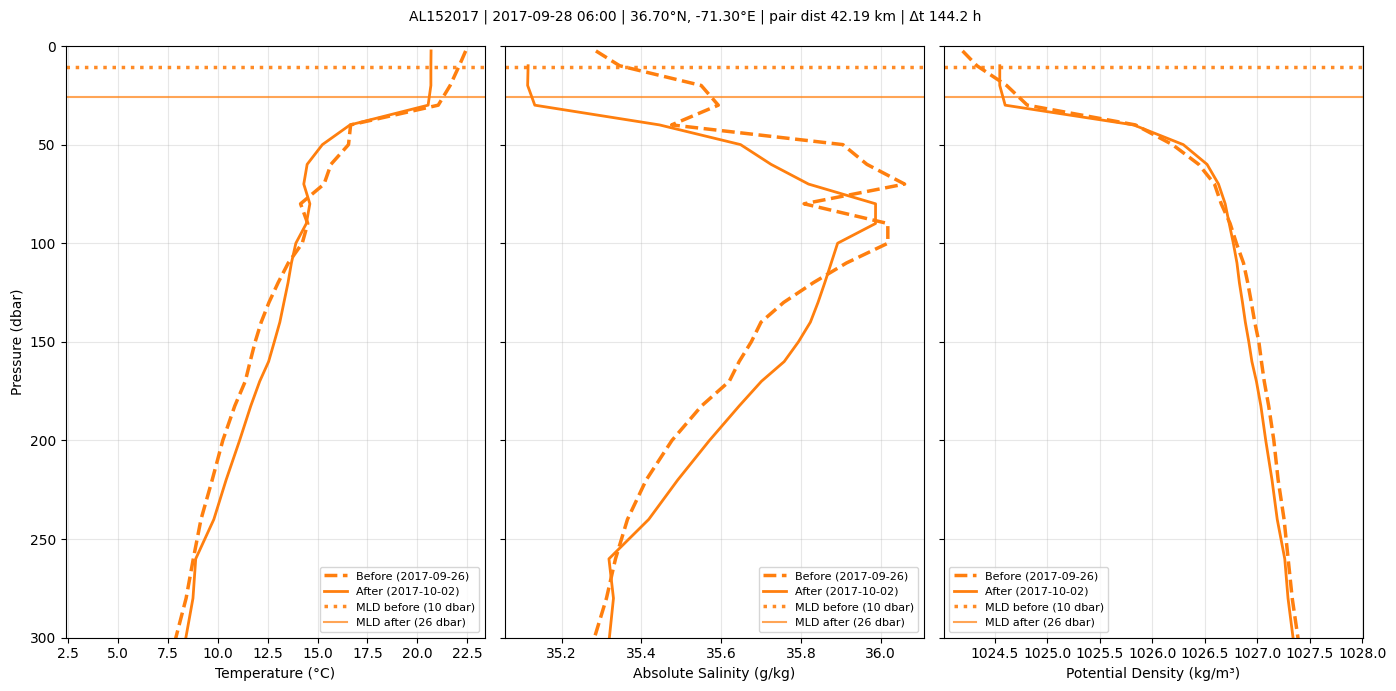

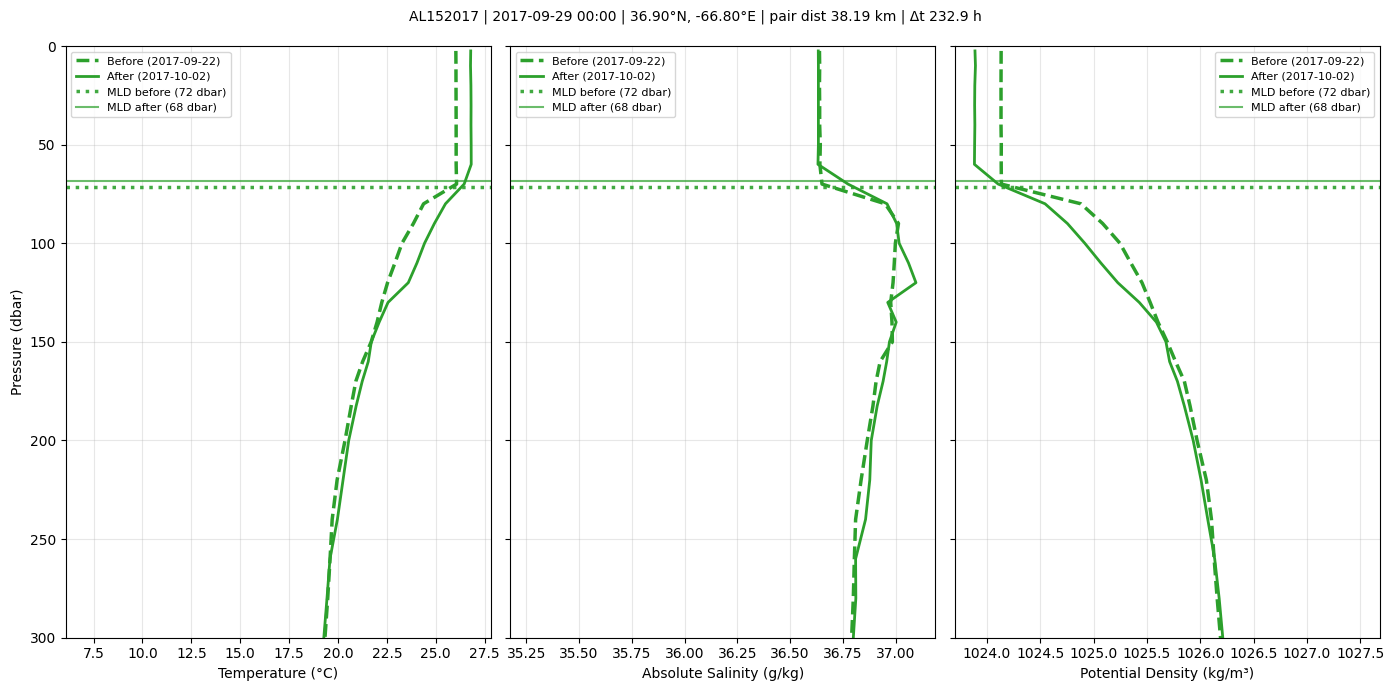

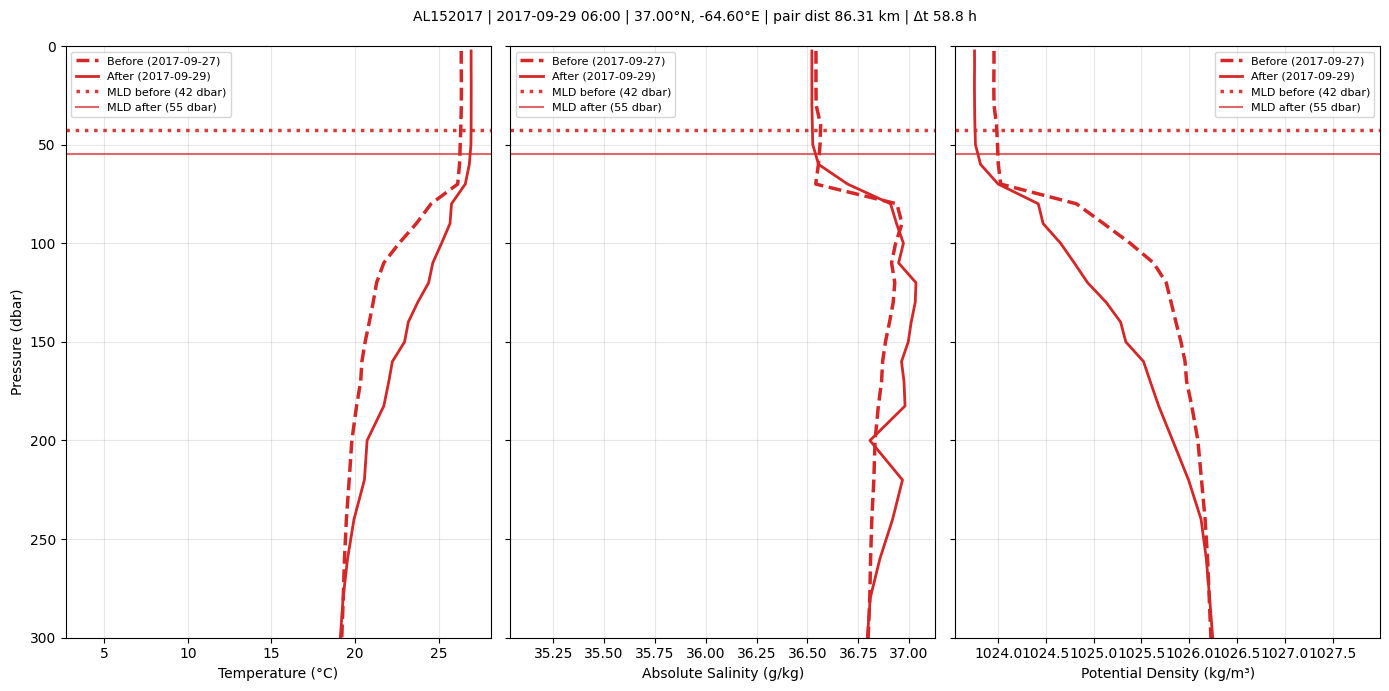

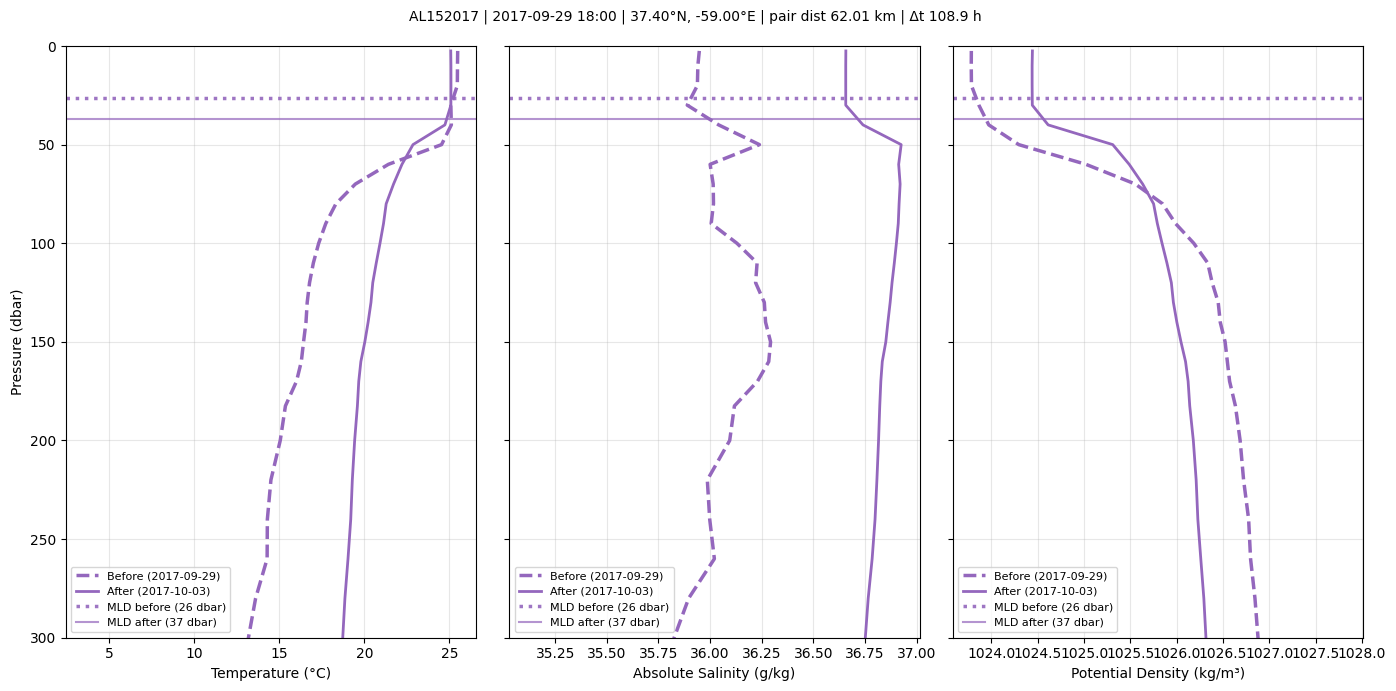

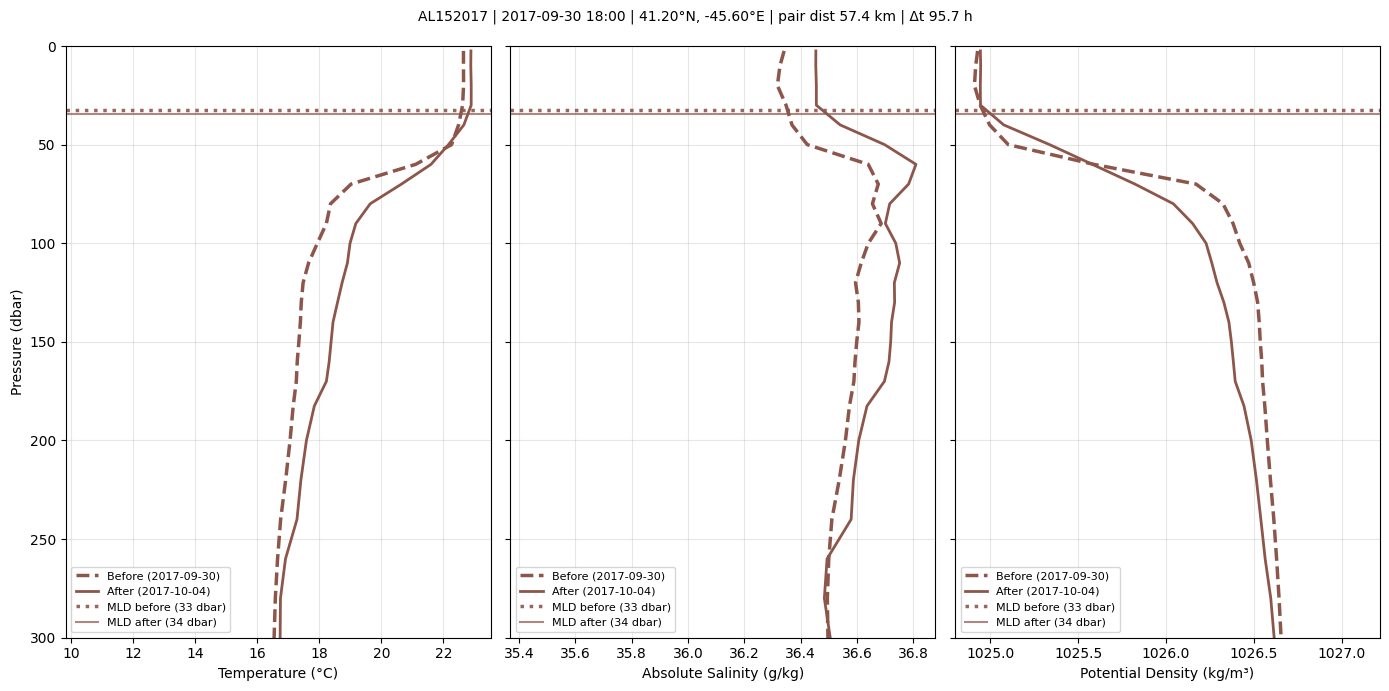

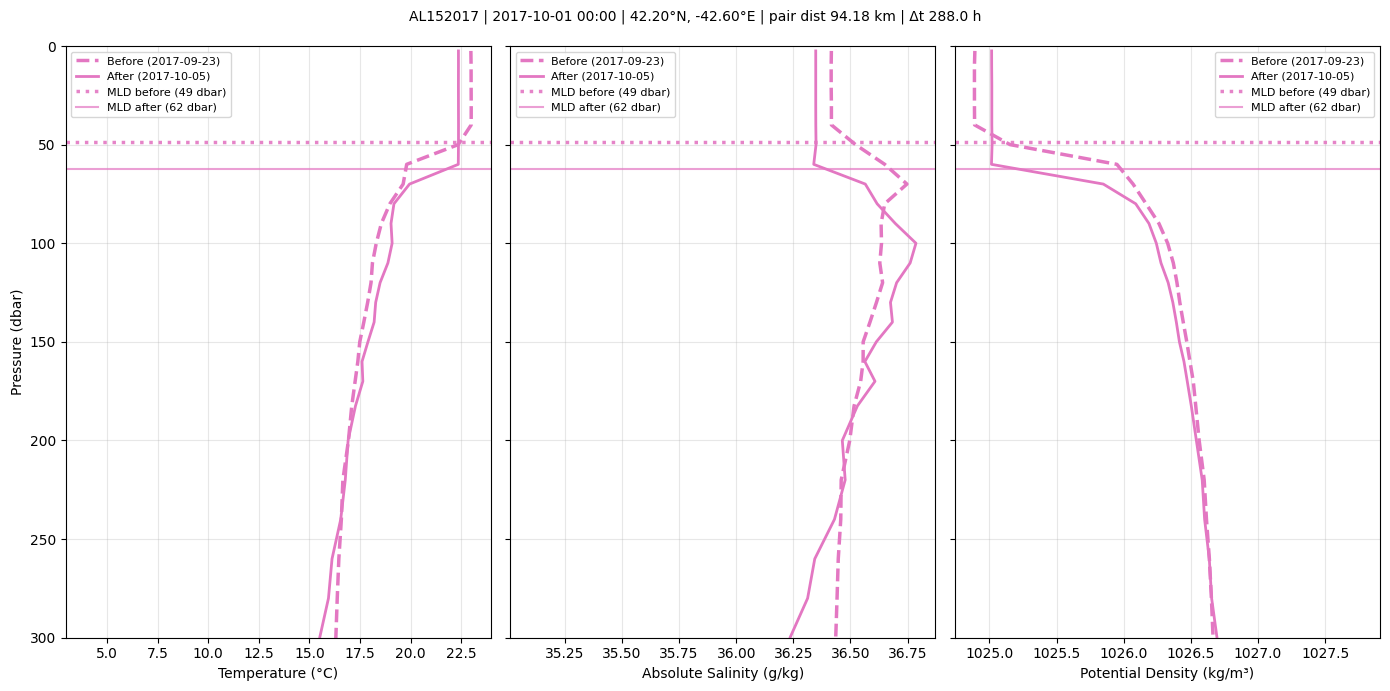

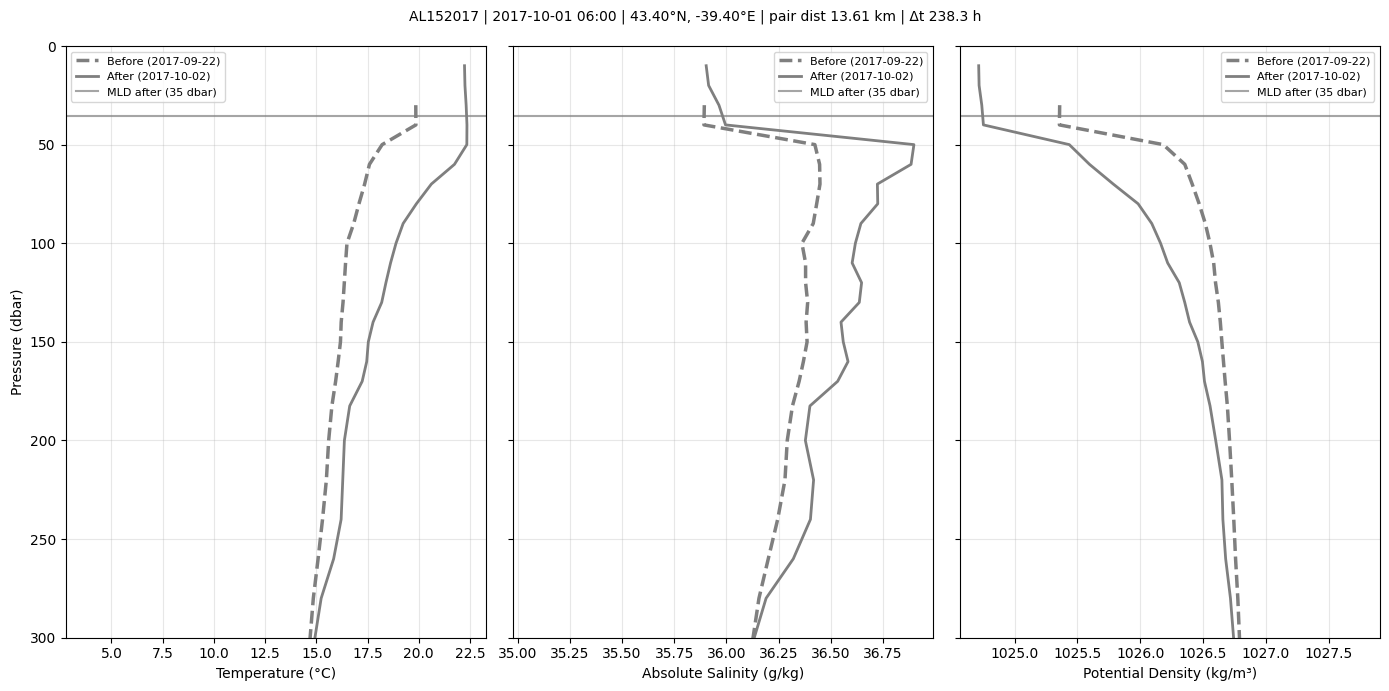

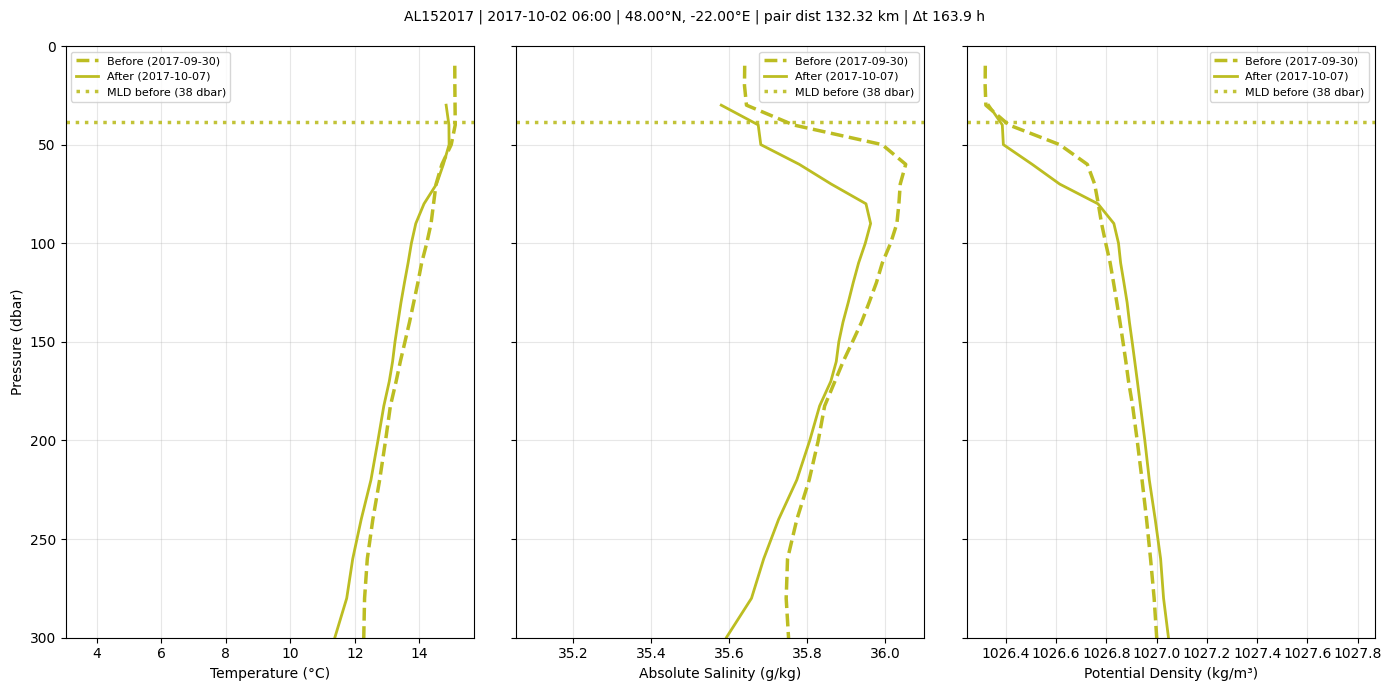

In [15]:
# ── Before/after profile pairs — run, do not modify ────────────────────────
for storm_id in all_paired:
    plot_storm_profile_pairs(storm_id, all_result_track_pts[storm_id],
                             all_insitu_deduplicated[storm_id],
                             max_plots=50, depth_ylim=DEPTH_YLIM,
                             all_paired=all_paired, show_mld=True)

## Visualization — Mean ΔT and ΔS across all TCs

Mean temperature and salinity anomaly profiles (after − before) averaged across all storms and all assigned pairs. The left panel shows the net cooling signal (ΔT) and the right panel shows the net salinity change (ΔS). The dashed vertical line marks zero; deviations to the left (ΔT < 0) indicate TC-driven cooling.

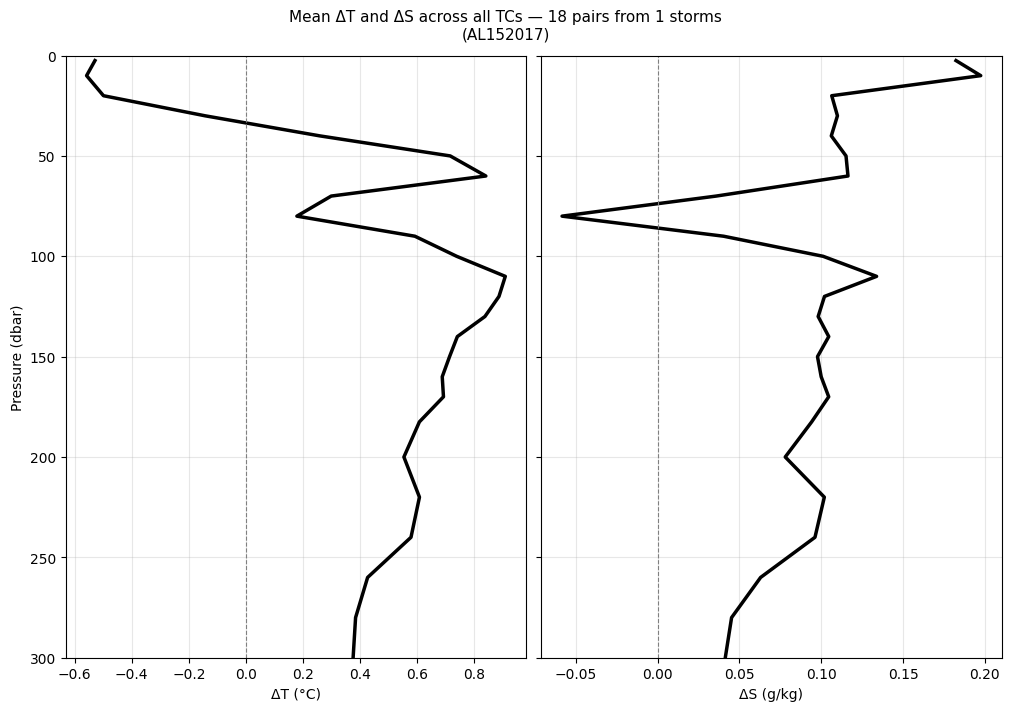

In [16]:
# ── Mean profiles across all TCs — run, do not modify ──────────────────────
plot_mean_across_storms(all_paired, depth_ylim=DEPTH_YLIM)

## ✏️ Student Work — Question 1: Upper-Ocean Temperature Response to TC Passage

Using the before/after profile pairs and the mean ΔT profile, describe how upper-ocean temperature changes following the passage of the tropical cyclone. At what depths is the change largest? Is the sign of the change the same at all depths? Which physical processes (wind-driven mixing, entrainment of cooler thermocline water, upwelling, surface heat loss) drive the observed change, and why?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 2: Precipitation and Upper-Ocean Salinity

Discuss the effect of cyclone-related precipitation on the upper ocean and evaluate whether this signal is evident in the observations (i.e. in the salinity changes with the TC passage).

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 3: Why Is the Precipitation Signal Weak?

Explain possible reasons why cyclone-related precipitation signals may be weak or difficult to detect from the Argo profile pairs we are considering here.

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 4: Seasonal Cycle Bias (Extra Credit)

How can the seasonal cycle create a bias in the before/after temperature difference signal? *(References: Hu et al., 2024; Sala et al., 2024)*

*Double-click to edit this cell and write your answer.*

## Part 2 — Explore Another Storm

> **📄 Before you continue:** Save a record of your Part 1 work now (e.g. **File → Print Preview**, or **File → Save and Export Notebook As → PDF/HTML**). Re-running the configuration cell with a new storm will overwrite the plots and answers above, so this is your only chance to keep a copy of Part 1.

✏️ **Student Work — Choose a Different TC**

Go back to the **Setup: configuration** cell and try a different storm or year.

Things to vary:
- **A storm in a different basin** — Western Pacific IDs start with `WP`, Eastern Pacific with `EP`, Indian Ocean with `IO`, Southern Hemisphere with `SH`. To discover exact IDs, set `target_ids = []` for that year and scan the printed list for the storm name.


  Once you find the ID, set e.g. `target_ids = ["WP312013"]` and re-run from Step 1. Fetching colocated profiles for every track point takes a few minutes per storm, and adding more storms multiplies that wait — so query a single storm first, confirm the workflow runs end to end, and only then add more.
- **A stronger or weaker storm** — compare a major hurricane with a tropical storm
- **A different `radius_km` or `delta_days`** — observe how the number of pairs changes

Do the delta profiles look different? Does the cooling signal change with storm intensity or basin?

### References

- **Hu et al. (2024)** — Hu, A. J., Kuusela, M., Lee, A. B., Giglio, D., and Wood, K. M.: Spatiotemporal methods for estimating subsurface ocean thermal response to tropical cyclones, *Adv. Stat. Clim. Meteorol. Oceanogr.*, 10, 69–93, https://doi.org/10.5194/ascmo-10-69-2024, 2024.

- **Sala et al. (2024)** — Sala, J., Giglio, D., Hu, A., Kuusela, M., Wood, K. M., and Lee, A. B.: Upper-ocean changes with hurricane-strength wind events: a study using Argo profiles and an ocean reanalysis, *Ocean Sci.*, 20, 1441–1455, https://doi.org/10.5194/os-20-1441-2024, 2024.